train 데이터 크기: (262, 21)
SNP 정보 데이터 크기: (15, 5)


,id,father,mother,gender,trait,SNP_01,SNP_02,SNP_03,SNP_04,SNP_05,...,SNP_07,SNP_08,SNP_09,SNP_10,SNP_11,SNP_12,SNP_13,SNP_14,SNP_15,class
0,TRAIN_000,0,0,0,2,G G,A G,A A,G A,C A,...,A A,G G,A A,G G,A G,A A,A A,A A,A A,B
1,TRAIN_001,0,0,0,2,A G,A G,C A,A A,A A,...,A A,G A,A A,A G,A A,G A,G G,A A,A A,C
2,TRAIN_002,0,0,0,2,G G,G G,A A,G A,C C,...,A A,G A,G A,A G,A A,A A,A A,A A,A A,B
3,TRAIN_003,0,0,0,1,A A,G G,A A,G A,A A,...,G G,A A,G G,A G,G G,G G,G G,A A,G G,A
4,TRAIN_004,0,0,0,2,G G,G G,C C,A A,C C,...,A A,A A,A A,G G,A A,A A,A G,A A,G A,C


,SNP_id,name,chrom,cm,pos
0,SNP_01,BTA-19852-no-rs,2,67.0546,42986890
1,SNP_02,ARS-USMARC-Parent-DQ647190-rs29013632,6,31.1567,13897068
2,SNP_03,ARS-BFGL-NGS-117009,6,68.2892,44649549
3,SNP_04,ARS-BFGL-NGS-60567,6,77.8749,53826064
4,SNP_05,BovineHD0600017032,6,80.5015,61779512


<class 'pandas.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      262 non-null    str  
 1   father  262 non-null    int64
 2   mother  262 non-null    int64
 3   gender  262 non-null    int64
 4   trait   262 non-null    int64
 5   SNP_01  262 non-null    str  
 6   SNP_02  262 non-null    str  
 7   SNP_03  262 non-null    str  
 8   SNP_04  262 non-null    str  
 9   SNP_05  262 non-null    str  
 10  SNP_06  262 non-null    str  
 11  SNP_07  262 non-null    str  
 12  SNP_08  262 non-null    str  
 13  SNP_09  262 non-null    str  
 14  SNP_10  262 non-null    str  
 15  SNP_11  262 non-null    str  
 16  SNP_12  262 non-null    str  
 17  SNP_13  262 non-null    str  
 18  SNP_14  262 non-null    str  
 19  SNP_15  262 non-null    str  
 20  class   262 non-null    str  
dtypes: int64(4), str(17)
memory usage: 43.1 KB
None
SNP 컬럼: ['SNP_01', 'SNP_02', 'SNP_03', 'SNP_04',

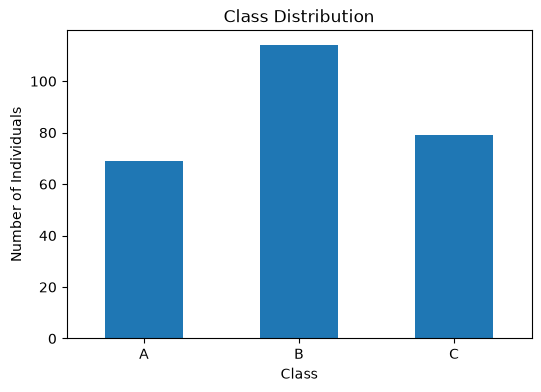

In [6]:
# 패키지 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# 머신러닝
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

# XGBoost
from xgboost import XGBClassifier

import time
import warnings
warnings.filterwarnings("ignore")

# 데이터 불러오기 및 확인
df = pd.read_csv("train.csv")
snp_info = pd.read_csv("snp_info.csv")

print("train 데이터 크기:", df.shape)
print("SNP 정보 데이터 크기:", snp_info.shape)

display(df.head())
display(snp_info.head())
print(df.info())

# snp 컬럼만 추출
snp_cols = [f"SNP_{i:02d}" for i in range(1, 16)]

print("SNP 컬럼:" , snp_cols)

# 데이터 타입 확인
df.info()

# 데이터 품질 확인
## 결측치 
print("결측치", df.isnull().sum())

## 중복 확인
print("전체 중복 행:", df.duplicated().sum())
print("중복 ID:", df["id"].duplicated().sum())
df[df["id"].duplicated(keep=False)].sort_values("id") # id 중복

# class 분포 분석
class_counts = df["class"].value_counts().sort_index()
print(class_counts)
## 시각화
plt.figure(figsize=(6, 4))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=0)

plt.show()


In [ ]:
for col in snp_cols:
    counts = df[col].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")

    plt.title(f"{col} Genotype Distribution")
    plt.xlabel("Genotype")
    plt.ylabel("Count")
    plt.xticks(rotation=0)

    plt.show()